Loaded 10324 triples

Top entities by raw frequency:
                             entity  raw_frequency  doc_frequency  mentions_per_paper
                         solubility            690            147                4.69
             water holding capacity            435            112                3.88
                    ultrasonication            359             21               17.10
               oil holding capacity            341             91                3.75
            emulsification activity            280             77                3.64
                   foaming capacity            266             84                3.17
                      pH adjustment            255             33                7.73
high hydrostatic pressure treatment            249              6               41.50
         emulsifying activity index            220             63                3.49
              cold plasma treatment            211              6               35.17



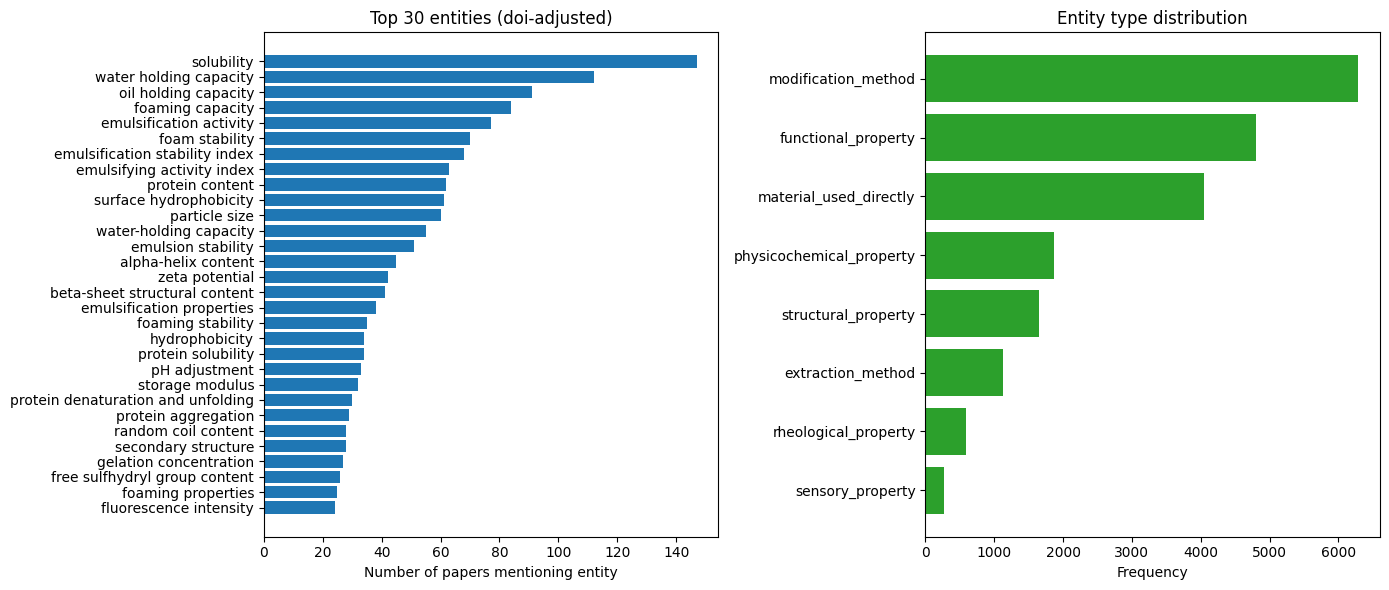


Saved plot to frequency_analysis.png
Saved frequency tables to frequency_analysis.xlsx


In [1]:
"""
Entity and entity-type frequency analysis for the extracted triple
knowledge graph.

Mirrors the PlantConnectome analysis (Fig. 3C/3D): counts which
entities occur most often, and checks whether the entity type
distribution matches what the literature filtering criteria would
predict. Relationship/interaction frequency removed by request.

Designed for Jupyter/Colab execution. No __main__ guard.
"""

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------
TRIPLES_PATH = "type_resolved_triples_v2.xlsx"
SOURCE_COL = "resolved_source"   # entity-name column at this pipeline stage
TARGET_COL = "resolved_target"
SOURCE_TYPE_COL = "source_type"  # closed-taxonomy type label, NOT the entity name column
TARGET_TYPE_COL = "target_type"
DOI_COL = "doi"

TOP_N = 30
OUTPUT_XLSX = "frequency_analysis.xlsx"
OUTPUT_PLOT = "frequency_analysis.png"


# ---------------------------------------------------------------
# LOAD
# ---------------------------------------------------------------
def load_triples(path):
    if path.endswith(".parquet"):
        return pd.read_parquet(path)
    elif path.endswith(".xlsx"):
        return pd.read_excel(path)
    elif path.endswith(".csv"):
        return pd.read_csv(path)
    else:
        raise ValueError(f"Unsupported file type: {path}")


df = load_triples(TRIPLES_PATH)
print(f"Loaded {len(df)} triples")

# ---------------------------------------------------------------
# ENTITY FREQUENCY: raw triple count AND doi-adjusted document
# frequency (unique papers mentioning the entity at least once).
# Raw count can be inflated by a small number of papers that mention
# the same entity repeatedly, e.g. one paper contributing 15 separate
# solubility triples. Document frequency avoids that inflation.
# ---------------------------------------------------------------
source_long = df[[SOURCE_COL, DOI_COL]].rename(columns={SOURCE_COL: "entity"})
target_long = df[[TARGET_COL, DOI_COL]].rename(columns={TARGET_COL: "entity"})
entity_long = pd.concat([source_long, target_long])
entity_long["entity"] = entity_long["entity"].astype(str).str.strip()

raw_freq = entity_long["entity"].value_counts().reset_index()
raw_freq.columns = ["entity", "raw_frequency"]

doc_freq = entity_long.groupby("entity")[DOI_COL].nunique().reset_index()
doc_freq.columns = ["entity", "doc_frequency"]

entity_freq = raw_freq.merge(doc_freq, on="entity")
entity_freq["mentions_per_paper"] = (entity_freq["raw_frequency"] / entity_freq["doc_frequency"]).round(2)
entity_freq = entity_freq.sort_values("doc_frequency", ascending=False).reset_index(drop=True)

print("\nTop entities by raw frequency:")
print(entity_freq.sort_values("raw_frequency", ascending=False).head(10).to_string(index=False))

print("\nTop entities by document frequency (doi-adjusted):")
print(entity_freq.head(10).to_string(index=False))

print("\nHighest mentions-per-paper (potential redundancy/chunking artifact, min 5 papers):")
print(entity_freq[entity_freq["doc_frequency"] >= 5]
      .sort_values("mentions_per_paper", ascending=False).head(10).to_string(index=False))

# ---------------------------------------------------------------
# ENTITY TYPE DISTRIBUTION (source_type and target_type combined)
# ---------------------------------------------------------------
entity_types = pd.concat([
    df[SOURCE_TYPE_COL].astype(str).str.strip(),
    df[TARGET_TYPE_COL].astype(str).str.strip(),
])
type_freq = entity_types.value_counts().reset_index()
type_freq.columns = ["entity_type", "frequency"]
type_freq["pct_of_total"] = (type_freq["frequency"] / type_freq["frequency"].sum() * 100).round(2)

print("\nEntity type distribution:")
print(type_freq.to_string(index=False))

# ---------------------------------------------------------------
# TYPE BREAKDOWN SPLIT BY SOURCE VS TARGET (source_type and
# target_type often carry different roles, e.g. modification_method
# tends to sit on source, functional_property tends to sit on target)
# ---------------------------------------------------------------
source_type_freq = df[SOURCE_TYPE_COL].astype(str).str.strip().value_counts().reset_index()
source_type_freq.columns = ["source_type", "frequency"]

target_type_freq = df[TARGET_TYPE_COL].astype(str).str.strip().value_counts().reset_index()
target_type_freq.columns = ["target_type", "frequency"]

# ---------------------------------------------------------------
# PLOTS
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_entities = entity_freq.head(TOP_N).iloc[::-1]
axes[0].barh(top_entities["entity"], top_entities["doc_frequency"], color="tab:blue")
axes[0].set_title(f"Top {TOP_N} entities (doi-adjusted)")
axes[0].set_xlabel("Number of papers mentioning entity")

axes[1].barh(type_freq["entity_type"].iloc[::-1], type_freq["frequency"].iloc[::-1], color="tab:green")
axes[1].set_title("Entity type distribution")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=200)
plt.show()
print(f"\nSaved plot to {OUTPUT_PLOT}")

# ---------------------------------------------------------------
# SAVE WORKBOOK
# ---------------------------------------------------------------
with pd.ExcelWriter(OUTPUT_XLSX) as writer:
    entity_freq.to_excel(writer, sheet_name="entity_frequency", index=False)
    type_freq.to_excel(writer, sheet_name="entity_type_distribution", index=False)
    source_type_freq.to_excel(writer, sheet_name="source_type_only", index=False)
    target_type_freq.to_excel(writer, sheet_name="target_type_only", index=False)

print(f"Saved frequency tables to {OUTPUT_XLSX}")

Loaded 10324 triples

Top entities by raw frequency:
                             entity  raw_frequency  doc_frequency  mentions_per_paper
                         solubility            690            147                4.69
            emulsification activity            500            116                4.31
             water holding capacity            435            112                3.88
                    ultrasonication            359             21               17.10
               oil holding capacity            341             91                3.75
     emulsification stability index            331            105                3.15
                   foaming capacity            266             84                3.17
                      pH adjustment            255             33                7.73
high hydrostatic pressure treatment            249              6               41.50
              cold plasma treatment            211              6               35.17



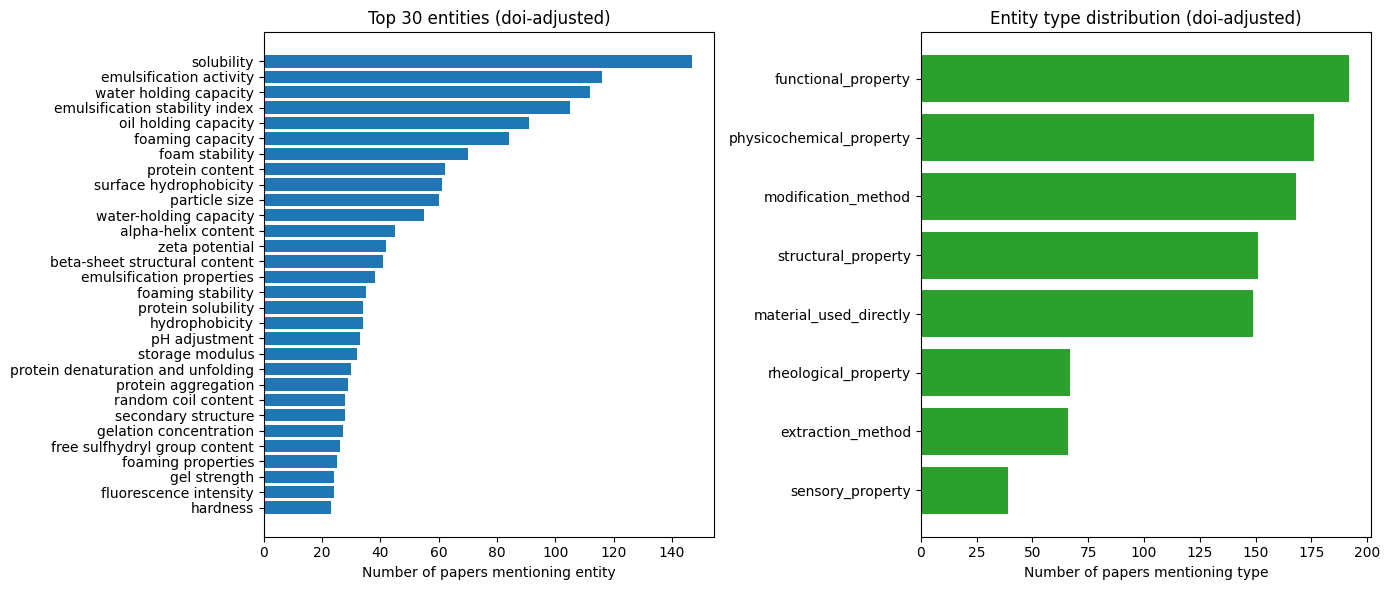


Saved plot to frequency_analysis.png
Saved frequency tables to frequency_analysis.xlsx


In [4]:
"""
Entity and entity-type frequency analysis for the extracted triple
knowledge graph.

Mirrors the PlantConnectome analysis (Fig. 3C/3D): counts which
entities occur most often, and checks whether the entity type
distribution matches what the literature filtering criteria would
predict. Relationship/interaction frequency removed by request.

Designed for Jupyter/Colab execution. No __main__ guard.
"""

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------
TRIPLES_PATH = "type_resolved_triples_v2.xlsx"
SOURCE_COL = "resolved_source"   # entity-name column at this pipeline stage
TARGET_COL = "resolved_target"
SOURCE_TYPE_COL = "source_type"  # closed-taxonomy type label, NOT the entity name column
TARGET_TYPE_COL = "target_type"
DOI_COL = "doi"

TOP_N = 30
OUTPUT_XLSX = "frequency_analysis.xlsx"
OUTPUT_PLOT = "frequency_analysis.png"


# ---------------------------------------------------------------
# LOAD
# ---------------------------------------------------------------
def load_triples(path):
    if path.endswith(".parquet"):
        return pd.read_parquet(path)
    elif path.endswith(".xlsx"):
        return pd.read_excel(path)
    elif path.endswith(".csv"):
        return pd.read_csv(path)
    else:
        raise ValueError(f"Unsupported file type: {path}")


df = load_triples(TRIPLES_PATH)
print(f"Loaded {len(df)} triples")

# ---------------------------------------------------------------
# OPTIONAL: display-only aliasing for the frequency chart/table.
# Does NOT touch resolved_source/resolved_target in the real data,
# only affects entity_freq counts and the chart below. Toggle off by
# setting APPLY_DISPLAY_ALIASES = False.
#
# Only combines entities CONFIRMED to be the same measurement by
# checking actual sentences, e.g. "emulsification activity" and
# "emulsifying activity index" both explicitly reference "EAI" in
# their source text. Deliberately does NOT combine EAI-family with
# ESI-family (emulsification/emulsion stability), those are two
# different standard measurements, confirmed by a sentence that
# explicitly contrasts "stabilizing emulsions" against "emulsifying
# activity" in the same breath, not a wording variant of one thing.
# ---------------------------------------------------------------
APPLY_DISPLAY_ALIASES = True

DISPLAY_ALIASES = {
    "emulsifying activity index": "emulsification activity",
    "emulsion stability": "emulsification stability index",
}

if APPLY_DISPLAY_ALIASES:
    def apply_display_alias(col):
        return col.astype(str).str.strip().replace(
            {k: v for k, v in DISPLAY_ALIASES.items()},
        )
    # applied to COPIES used only for entity_freq below, df itself
    # (and therefore the type-distribution counts) is untouched
    display_source = apply_display_alias(df[SOURCE_COL])
    display_target = apply_display_alias(df[TARGET_COL])
else:
    display_source = df[SOURCE_COL]
    display_target = df[TARGET_COL]

# ---------------------------------------------------------------
# ENTITY FREQUENCY: raw triple count AND doi-adjusted document
# frequency (unique papers mentioning the entity at least once).
# Raw count can be inflated by a small number of papers that mention
# the same entity repeatedly, e.g. one paper contributing 15 separate
# solubility triples. Document frequency avoids that inflation.
# ---------------------------------------------------------------
source_long = pd.DataFrame({"entity": display_source, DOI_COL: df[DOI_COL]})
target_long = pd.DataFrame({"entity": display_target, DOI_COL: df[DOI_COL]})
entity_long = pd.concat([source_long, target_long])
entity_long["entity"] = entity_long["entity"].astype(str).str.strip()

raw_freq = entity_long["entity"].value_counts().reset_index()
raw_freq.columns = ["entity", "raw_frequency"]

doc_freq = entity_long.groupby("entity")[DOI_COL].nunique().reset_index()
doc_freq.columns = ["entity", "doc_frequency"]

entity_freq = raw_freq.merge(doc_freq, on="entity")
entity_freq["mentions_per_paper"] = (entity_freq["raw_frequency"] / entity_freq["doc_frequency"]).round(2)
entity_freq = entity_freq.sort_values("doc_frequency", ascending=False).reset_index(drop=True)

print("\nTop entities by raw frequency:")
print(entity_freq.sort_values("raw_frequency", ascending=False).head(10).to_string(index=False))

print("\nTop entities by document frequency (doi-adjusted):")
print(entity_freq.head(10).to_string(index=False))

print("\nHighest mentions-per-paper (potential redundancy/chunking artifact, min 5 papers):")
print(entity_freq[entity_freq["doc_frequency"] >= 5]
      .sort_values("mentions_per_paper", ascending=False).head(10).to_string(index=False))

# ---------------------------------------------------------------
# ENTITY TYPE DISTRIBUTION (source_type and target_type combined),
# same raw-vs-doi-adjusted treatment as entity frequency above. A
# type used many times within a small number of papers otherwise
# looks more prevalent across the corpus than it really is.
# ---------------------------------------------------------------
type_long = pd.concat([
    pd.DataFrame({"entity_type": df[SOURCE_TYPE_COL].astype(str).str.strip(), DOI_COL: df[DOI_COL]}),
    pd.DataFrame({"entity_type": df[TARGET_TYPE_COL].astype(str).str.strip(), DOI_COL: df[DOI_COL]}),
])

type_raw_freq = type_long["entity_type"].value_counts().reset_index()
type_raw_freq.columns = ["entity_type", "raw_frequency"]

type_doc_freq = type_long.groupby("entity_type")[DOI_COL].nunique().reset_index()
type_doc_freq.columns = ["entity_type", "doc_frequency"]

type_freq = type_raw_freq.merge(type_doc_freq, on="entity_type")
type_freq["pct_of_total_papers"] = (type_freq["doc_frequency"] / df[DOI_COL].nunique() * 100).round(2)
type_freq = type_freq.sort_values("doc_frequency", ascending=False).reset_index(drop=True)

print("\nEntity type distribution (doi-adjusted):")
print(type_freq.to_string(index=False))

# ---------------------------------------------------------------
# TYPE BREAKDOWN SPLIT BY SOURCE VS TARGET (source_type and
# target_type often carry different roles, e.g. modification_method
# tends to sit on source, functional_property tends to sit on target)
# ---------------------------------------------------------------
source_type_freq = df[SOURCE_TYPE_COL].astype(str).str.strip().value_counts().reset_index()
source_type_freq.columns = ["source_type", "frequency"]

target_type_freq = df[TARGET_TYPE_COL].astype(str).str.strip().value_counts().reset_index()
target_type_freq.columns = ["target_type", "frequency"]

# ---------------------------------------------------------------
# PLOTS
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_entities = entity_freq.head(TOP_N).iloc[::-1]
axes[0].barh(top_entities["entity"], top_entities["doc_frequency"], color="tab:blue")
axes[0].set_title(f"Top {TOP_N} entities (doi-adjusted)")
axes[0].set_xlabel("Number of papers mentioning entity")

axes[1].barh(type_freq["entity_type"].iloc[::-1], type_freq["doc_frequency"].iloc[::-1], color="tab:green")
axes[1].set_title("Entity type distribution (doi-adjusted)")
axes[1].set_xlabel("Number of papers mentioning type")

plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=600)
plt.show()
print(f"\nSaved plot to {OUTPUT_PLOT}")

# ---------------------------------------------------------------
# SAVE WORKBOOK
# ---------------------------------------------------------------
with pd.ExcelWriter(OUTPUT_XLSX) as writer:
    entity_freq.to_excel(writer, sheet_name="entity_frequency", index=False)
    type_freq.to_excel(writer, sheet_name="entity_type_distribution", index=False)
    source_type_freq.to_excel(writer, sheet_name="source_type_only", index=False)
    target_type_freq.to_excel(writer, sheet_name="target_type_only", index=False)

print(f"Saved frequency tables to {OUTPUT_XLSX}")